In [ ]:
import os
from tensorflow.keras.utils import get_file

file_path = '../data/Jena_Climate'
os.makedirs(file_path, exist_ok=True)

donwloaded_dile = get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
    cache_dir=file_path 
)

In [1]:
import numpy as np
import pandas as pd

DATA_PATH = '../data/jena_Climate/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv'

data = pd.read_csv(DATA_PATH)
data.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [2]:
df = data.drop(columns=['Date Time'])
df.isna().sum()


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

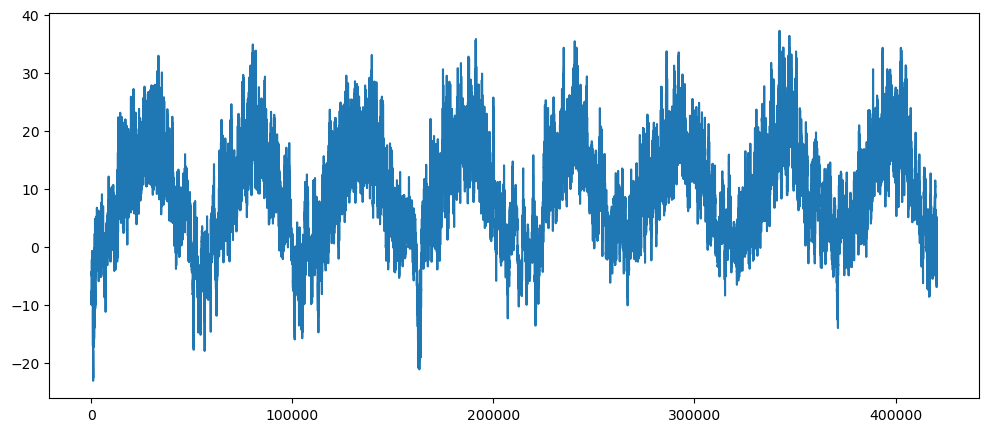

In [3]:
#Overall view of the temperature 
from matplotlib import pyplot as plt

temperature = df['T (degC)']
plt.figure(figsize=(12,5))
plt.plot(range(len(temperature)), temperature)
plt.show()

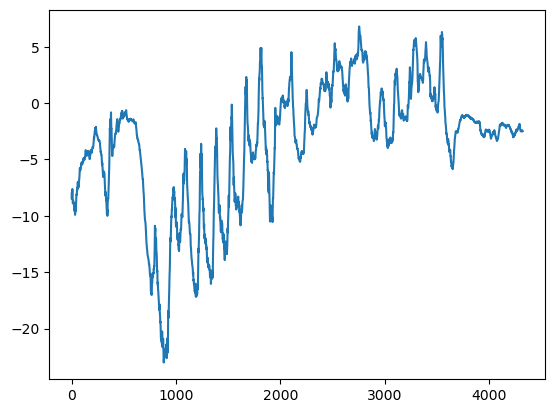

In [4]:
#Temperature over the firts 30 days
plt.plot(range(4320), temperature[:4320])
plt.show()

In [5]:
#Data preparation
from sklearn.preprocessing import StandardScaler
n_train_samples = int(0.5 * df.shape[0])
n_val_samples = int(0.25 * df.shape[0])
n_test_samples = df.shape[0] - n_train_samples - n_val_samples

data = df[:]
target = temperature[:]

scaler = StandardScaler()
scaler.fit(data[:n_train_samples].values)
train_data = scaler.transform(data[:n_train_samples].values)
val_data = scaler.transform(data[n_train_samples:n_train_samples + n_val_samples].values)
test_data = scaler.transform(data[n_train_samples + n_val_samples:].values)
y_train = target[:n_train_samples]
y_val = target[n_train_samples : n_train_samples+n_val_samples]
y_test = target[n_train_samples+n_val_samples:]

In [6]:
from tensorflow import keras

sampling_rate = 6 
sequence_length = 120
delay = sampling_rate*(sequence_length+24-1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    train_data[:-delay], 
    targets=y_train[delay:],
    sampling_rate=sampling_rate, 
    sequence_length=sequence_length,
    shuffle=True, 
    batch_size=batch_size, 
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    val_data[:-delay], 
    targets=y_val[delay:],
    sampling_rate=sampling_rate, 
    sequence_length=sequence_length,
    shuffle=False, 
    batch_size=batch_size, 
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    test_data[:-delay],
    targets=y_test[delay:],
    sampling_rate=sampling_rate, 
    sequence_length=sequence_length,
    shuffle=False, 
    batch_size=batch_size, 
    start_index=0, 
    end_index=None
)

In [7]:
for samples, targets in train_dataset:
    print('samples shape: ', samples.shape)
    print('targets shape: ', targets.shape)
    break

samples shape:  (256, 120, 14)
targets shape:  (256,)


In [8]:
#Testing a basic model with densely layer model
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, df.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_dense.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_dense.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 13.0284 - mae: 2.7894 - val_loss: 10.2206 - val_mae: 2.5265
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 9.0120 - mae: 2.3582 - val_loss: 11.3061 - val_mae: 2.6671
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 8.2337 - mae: 2.2563 - val_loss: 12.9191 - val_mae: 2.8602
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 7.7761 - mae: 2.1910 - val_loss: 10.6536 - val_mae: 2.5962
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 7.4757 - mae: 2.1489 - val_loss: 12.5137 - val_mae: 2.8138
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 7.2447 - mae: 2.1157 - val_loss: 12.1730 - val_mae: 2.7612
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7.0937 - mae: 2.0937 - val_loss: 10.4877 - val_mae: 2.5732
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 6.9297 - mae: 2.0690 - val_loss: 14.9826 - val_mae: 3.0957
Epoch 9/10
816/816 ━━━━━━━━━━━━━━━━━━━

In [9]:
inputs = keras.Input(shape=(sequence_length, df.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks)
model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 21.5657 - mae: 3.6694 - val_loss: 15.7115 - val_mae: 3.1044
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 15.5976 - mae: 3.1430 - val_loss: 16.6704 - val_mae: 3.2559
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 14.1361 - mae: 2.9881 - val_loss: 13.9484 - val_mae: 2.9368
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 13.2091 - mae: 2.8848 - val_loss: 14.6295 - val_mae: 3.0111
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 12.5990 - mae: 2.8136 - val_loss: 15.9159 - val_mae: 3.1405
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 12.1167 - mae: 2.7574 - val_loss: 15.1422 - val_mae: 3.0534
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 11.7193 - mae: 2.7080 - val_loss: 14.7299 - val_mae: 2.9953
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 11.3422 - mae: 2.6640 - val_loss: 15.8338 - val_mae: 3.1220
Epoch 9/10
816/816 ━━━━━

In [10]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_lstm.keras',
                                    save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_lstm.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 45.5846 - mae: 4.9078 - val_loss: 13.3484 - val_mae: 2.7649
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 11.1673 - mae: 2.5954 - val_loss: 9.7215 - val_mae: 2.4160
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 9.8825 - mae: 2.4554 - val_loss: 9.5877 - val_mae: 2.3954
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 9.5509 - mae: 2.4122 - val_loss: 9.5223 - val_mae: 2.3874
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 9.3426 - mae: 2.3828 - val_loss: 9.3758 - val_mae: 2.3728
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 9.1015 - mae: 2.3486 - val_loss: 9.4053 - val_mae: 2.3786
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 8.9250 - mae: 2.3240 - val_loss: 9.6467 - val_mae: 2.4121
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 8.7691 - mae: 2.3013 - val_loss: 9.6972 - val_mae: 2.4164
Epoch 9/10
816/816 ━━━━━━━━━━━━━━━━━━

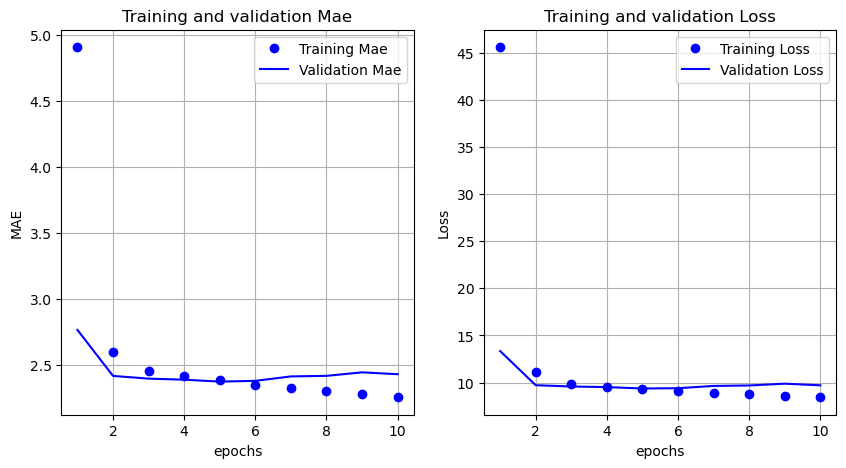

In [11]:
mae_lstm_model = history.history['mae']
val_mae_lstm_model = history.history['val_mae']
loss_lstm_model = history.history['loss']
val_loss_lstm_model = history.history['val_loss']

epochs = range(1, len(mae_lstm_model) + 1)

fig, ( axis1, axis2) = plt.subplots(1, 2, figsize=(10,5))

axis1.plot(epochs, mae_lstm_model, 'bo', label='Training Mae')
axis1.plot(epochs, val_mae_lstm_model, 'b', label='Validation Mae')
axis1.set_title('Training and validation Mae')
axis1.set_xlabel('epochs')
axis1.set_ylabel('MAE')
axis1.legend()
axis1.grid(True)

axis2.plot(epochs, loss_lstm_model, 'bo', label='Training Loss')
axis2.plot(epochs, val_loss_lstm_model, 'b', label='Validation Loss')
axis2.set_title('Training and validation Loss')
axis2.set_xlabel('epochs')
axis2.set_ylabel('Loss')
axis2.legend()
axis2.grid(True)

In [12]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x=layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x=layers.Dropout(0.5)(x)
outputs=layers.Dense(1)(x)
model=keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_lstm_dopout.keras',
                                    save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - loss: 30.6025 - mae: 4.0552 - val_loss: 9.5726 - val_mae: 2.4039
Epoch 2/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - loss: 15.0351 - mae: 3.0141 - val_loss: 9.1950 - val_mae: 2.3586
Epoch 3/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 14.2050 - mae: 2.9262 - val_loss: 9.0785 - val_mae: 2.3338
Epoch 4/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 13.7090 - mae: 2.8746 - val_loss: 9.1085 - val_mae: 2.3388
Epoch 5/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 13.2792 - mae: 2.8256 - val_loss: 9.1206 - val_mae: 2.3366
Epoch 6/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - loss: 13.0051 - mae: 2.8001 - val_loss: 9.0054 - val_mae: 2.3243
Epoch 7/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 12.7765 - mae: 2.7754 - val_loss: 9.0128 - val_mae: 2.3305
Epoch 8/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - loss: 12.5991 - mae: 2.7556 - val_loss: 8.9950 - val_mae: 2.3171
Epoch 9/50
816/816 ━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_stacked_gru_dropout.keras',
                                    save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_stacked_gru_dropout.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 167s 200ms/step - loss: 24.8068 - mae: 3.6885 - val_loss: 9.2371 - val_mae: 2.3436
Epoch 2/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 163s 200ms/step - loss: 14.2255 - mae: 2.9225 - val_loss: 9.4895 - val_mae: 2.4077
Epoch 3/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 164s 201ms/step - loss: 13.5678 - mae: 2.8527 - val_loss: 9.7510 - val_mae: 2.4373
Epoch 4/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 164s 201ms/step - loss: 13.0478 - mae: 2.7995 - val_loss: 8.6508 - val_mae: 2.2834
Epoch 5/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 164s 201ms/step - loss: 12.6718 - mae: 2.7613 - val_loss: 8.4352 - val_mae: 2.2483
Epoch 6/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 165s 202ms/step - loss: 12.2605 - mae: 2.7156 - val_loss: 8.3510 - val_mae: 2.2353
Epoch 7/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 166s 203ms/step - loss: 11.9855 - mae: 2.6866 - val_loss: 8.4485 - val_mae: 2.2524
Epoch 8/50
816/816 ━━━━━━━━━━━━━━━━━━━━ 167s 205ms/step - loss: 11.7040 - mae: 2.6569 - val_loss: 8.6822 - val_mae: 2.2913
Epoch 9/50
816/8

In [ ]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
    epochs=10, 
    validation_data=val_dataset)

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 56s 66ms/step - loss: 26.2716 - mae: 3.6959 - val_loss: 10.5646 - val_mae: 2.5004
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 63s 77ms/step - loss: 9.4891 - mae: 2.4053 - val_loss: 10.0858 - val_mae: 2.4364
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 61s 75ms/step - loss: 8.7143 - mae: 2.2989 - val_loss: 9.5216 - val_mae: 2.3580
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 63s 77ms/step - loss: 8.3339 - mae: 2.2485 - val_loss: 9.6140 - val_mae: 2.3773
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - loss: 7.9966 - mae: 2.2012 - val_loss: 9.7502 - val_mae: 2.3982
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - loss: 7.7123 - mae: 2.1602 - val_loss: 9.5629 - val_mae: 2.3887
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 64s 78ms/step - loss: 7.3687 - mae: 2.1113 - val_loss: 9.6028 - val_mae: 2.4011
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 63s 78ms/step - loss: 7.1326 - mae: 2.0772 - val_loss: 9.8133 - val_mae: 2.4275
Epoch 9/10
816/816 ━━━━━━━━━━━━━━━━━━

In [ ]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(x)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_stacked_gru_dropout.keras',
                                    save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_stacked_gru_dropout.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 148s 176ms/step - loss: 25.2321 - mae: 3.7117 - val_loss: 9.1256 - val_mae: 2.3338
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 160s 195ms/step - loss: 14.2122 - mae: 2.9248 - val_loss: 8.9201 - val_mae: 2.3247
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 167s 204ms/step - loss: 13.3116 - mae: 2.8309 - val_loss: 8.5604 - val_mae: 2.2682
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 161s 197ms/step - loss: 12.7092 - mae: 2.7685 - val_loss: 8.9585 - val_mae: 2.3270
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 163s 199ms/step - loss: 12.2703 - mae: 2.7183 - val_loss: 8.2750 - val_mae: 2.2314
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 155s 190ms/step - loss: 11.7255 - mae: 2.6623 - val_loss: 8.2737 - val_mae: 2.2376
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 160s 195ms/step - loss: 11.3482 - mae: 2.6203 - val_loss: 8.8581 - val_mae: 2.3153
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 159s 195ms/step - loss: 10.9761 - mae: 2.5765 - val_loss: 8.4563 - val_mae: 2.2592
Epoch 9/10
816/8

In [ ]:
inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_stacked_gru_dropout.keras',
                                    save_best_only=True)
]

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_stacked_gru_dropout.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

In [14]:
import keras_tuner as kt

def build_model(hp):
    hp_GRU_units1 = hp.Int('units1', min_value=16, max_value=64, step=16)
    hp_GRU_units2 = hp.Int('units2', min_value=16, max_value=64, step=16)

    hp_dropout_RNN = hp.Float('dropout_RNN', min_value=0.1, max_value=0.5, step=0.1)
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)

    hp_units3 = hp.Int('units3', min_value=32, max_value=96, step=32)
    
    model = keras.Sequential([
        keras.Input(shape=(sequence_length, data.shape[-1])),
        layers.GRU(units=hp_GRU_units1, recurrent_dropout=hp_dropout_RNN, return_sequences=True),
        layers.GRU(units=hp_GRU_units2, recurrent_dropout=hp_dropout_RNN),
        layers.Dropout(hp_dropout),
        layers.Dense(hp_units3, activation='relu'),
        layers.Dense(1)
    ])

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model

In [15]:
jena_tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_loss',
    max_trials=10, 
    executions_per_trial=3,
    overwrite=True,
    directory='hp_dir',
    project_name='jena_model_tuning'
)

jena_tuner.search(train_dataset, validation_data=val_dataset)

Trial 10 Complete [00h 26m 45s]
val_loss: 8.543752034505209

Best val_loss So Far: 8.543752034505209
Total elapsed time: 01h 34m 19s


In [21]:
best_hps = jena_tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = jena_tuner.get_best_models(num_models=1)[0]

print(f'Número de neuronas del primer GRU (units1): {best_hps.get("units1")}')
print(f'Number of layers of the first GRU: {best_hps.get("units1")}')
print(f'Number of layers of the second GRU: {best_hps.get("units2")}')
print(f'Dropout factor of the GRU layer: {best_hps.get("dropout_RNN")}')
print(f'Dropout factor: {best_hps.get("dropout")}')
print(f'Number of neurons: {best_hps.get("units3")}')
print(f'Learning rate: {best_hps.get("learning_rate")}')

best_model = jena_tuner.get_best_models(num_models=1)[0]

Número de neuronas del primer GRU (units1): 48
Number of layers of the first GRU: 48
Number of layers of the second GRU: 64
Dropout factor of the GRU layer: 0.30000000000000004
Dropout factor: 0.4
Number of neurons: 96
Learning rate: 0.001
